  Education   Income  Recency  ...  Children_at_home  Living_With  Family_Size
0  Graduate  58138.0       58  ...                 0        Alone            1
1  Graduate  46344.0       38  ...                 2        Alone            3
2  Graduate  71613.0       26  ...                 0      Partner            2
3  Graduate  26646.0       26  ...                 1      Partner            3
4       PhD  58293.0       94  ...                 1      Partner            3

[5 rows x 28 columns]


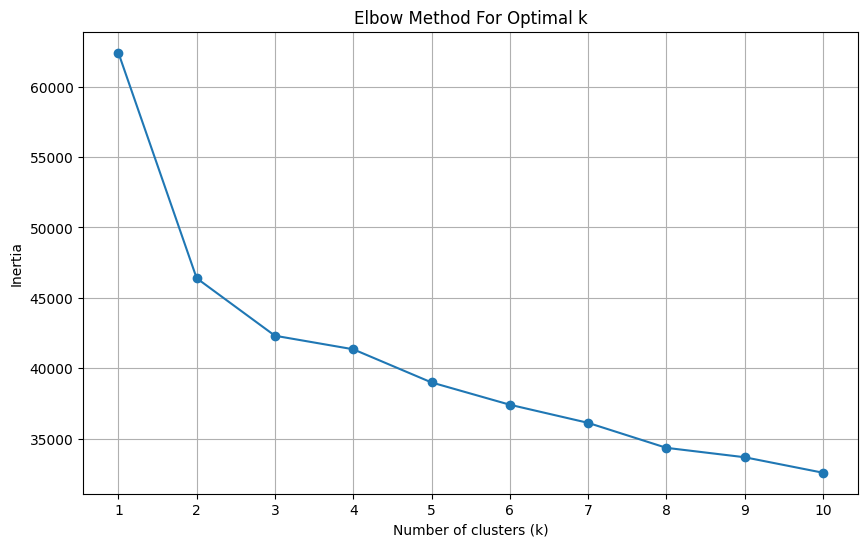

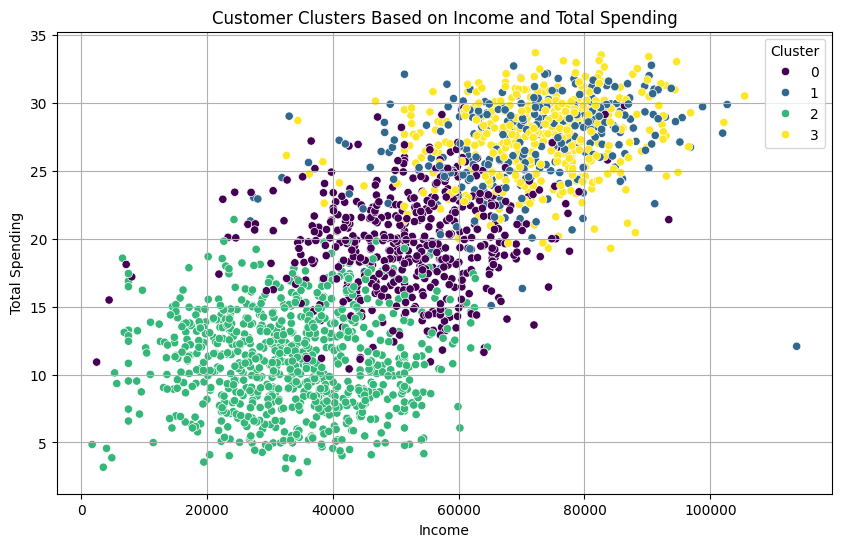

In [20]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

#Load data
file_path = "../data/preprocessed/marketing_campaign_preprocessed.csv"
data = pd.read_csv(file_path)

#Display first few rows of the DataFrame
print(data.head())

features = [
    'Education', 'Income', 'Recency', 
    'MntWines', 'MntFruits', 'MntMeatProducts', 
    'MntFishProducts', 'MntSweetProducts', 
    'MntGoldProds', 'NumDealsPurchases', 
    'NumWebPurchases', 'NumCatalogPurchases', 
    'NumStorePurchases', 'NumWebVisitsMonth', 
    'AcceptedCmp1', 'AcceptedCmp2', 
    'AcceptedCmp3', 'AcceptedCmp4', 
    'AcceptedCmp5', 'Age', 
    'Customer_Tenure_Days', 
    'Total_Spending', 'Total_Purchases', 
    'Children_at_home', 'Living_With', 'Family_Size'
]

X = data[features]

#Convert categorical variables to numerical
X = pd.get_dummies(X, drop_first=True) #One-hot encode categorical variables

#Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#Use the elbow method to determine the optimal number of clusters
inertia = [] #List to hold inertia values for each k
K = range(1, 11) #Test k values from 1 to 10

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42) #Create KMeans object
    kmeans.fit(X_scaled) #Fit the model
    inertia.append(kmeans.inertia_)

#Plot the elbow curve
plt.figure(figsize=(10, 6))
plt.plot(K, inertia, marker='o')
plt.title('Elbow Method For Optimal k')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.xticks(K)
plt.grid(True)
plt.show()

#Determine optimal k, then cluster data where k=4
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42) #Create KMeans object
data['Cluster'] = kmeans.fit_predict(X_scaled) #Fit and predict clusters

#Visualization
plt.figure(figsize=(10, 6))
sns.scatterplot(x=data['Income'], y=data['Total_Spending'], hue=data['Cluster'], palette='viridis', data=data)
plt.title('Customer Clusters Based on Income and Total Spending')
plt.xlabel('Income')
plt.ylabel('Total Spending')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

Average Characteristics of Each Cluster:
   Cluster        Income  ...  Children_at_home  Family_Size
0        0  52687.152372  ...          1.317518     3.010949
1        1  71628.929467  ...          0.338558     1.376176
2        2  33192.674251  ...          1.236404     2.883463
3        3  72518.627983  ...          0.386117     2.386117

[4 rows x 27 columns]


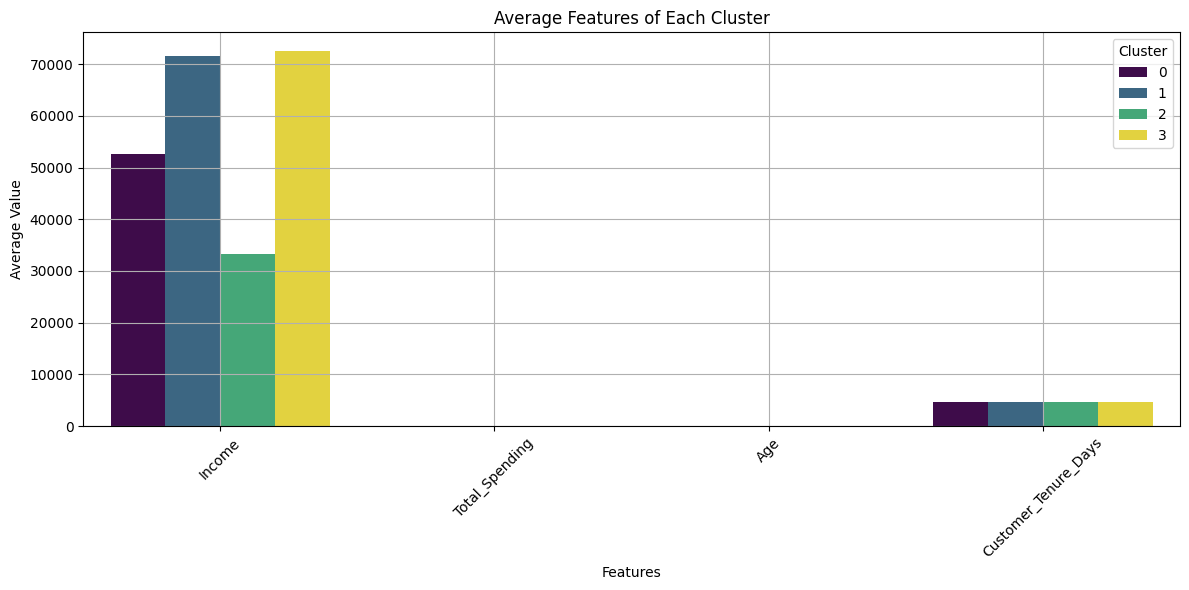

In [21]:
#experiment: analyze avg characteristics of each cluster

#Create copy
data_copy = data.copy()

#Check if the Cluster column exists
if 'Cluster' in data_copy.columns:
    data_copy = data_copy.drop(columns=['Cluster'])

#Calculate avg values of numeric features for each cluster
numeric_features = data_copy.select_dtypes(include=['number']).columns.tolist()

#Group by Cluster column from og DataFrame 
cluster_means = data.groupby('Cluster')[numeric_features].mean().reset_index() #Calculate means

#Display the average characteristics for each cluster
print("Average Characteristics of Each Cluster:")
print(cluster_means)

#Visualize the average values of important numeric features per cluster
features_to_plot = ['Income', 'Total_Spending', 'Age', 'Customer_Tenure_Days']
#Ensure the features are present in cluster_means
features_to_plot = [feature for feature in features_to_plot if feature in numeric_features]

#Melt the DataFrame for visualization
cluster_means_melted = cluster_means.melt(id_vars='Cluster', value_vars=features_to_plot, 
                                           var_name='Feature', value_name='Average Value')

#Bar plot
plt.figure(figsize=(12, 6))
sns.barplot(x='Feature', y='Average Value', hue='Cluster', data=cluster_means_melted, palette='viridis')
plt.title('Average Features of Each Cluster')
plt.xlabel('Features')
plt.ylabel('Average Value')
plt.legend(title='Cluster')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


In [22]:
#experiment: identify customer segments and build a predictive classification model

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import StandardScaler

#Create copy
data_copy = data.copy()

#Define the target variable (whether a customer accepts promotions)
#Assume 'AcceptedCmp1' indicates acceptance of a previous promotion (Description: 1 if customer accepted the offer in the 1st campaign, 0 otherwise)
target = data_copy['AcceptedCmp1']

#Prep features for the classification model by selecting relevant columns
features = [
    'Income', 'Recency', 
    'MntWines', 'MntFruits', 
    'Total_Spending', 'NumDealsPurchases', 
    'Cluster'
]
X = data_copy[features]

#Scale the features to improve model performance
scaler = StandardScaler()  #Create a StandardScaler object
X_scaled = scaler.fit_transform(X)  #Fit and transform the features

#Split dataset 80 train/20 test
X_train, X_test, y_train, y_test = train_test_split(X_scaled, target, test_size=0.2, random_state=42)

#Feature selection
selector = SelectKBest(score_func=f_classif, k='all')
X_train_selected = selector.fit_transform(X_train, y_train) #Fit and transform the training data
X_test_selected = selector.transform(X_test) #Transform

#Create and train the Logistic Regression classifier
clf = LogisticRegression(random_state=42, max_iter=200, solver='lbfgs')
clf.fit(X_train_selected, y_train) #Fit the model with training data

#Make predictions on the test set
y_pred = clf.predict(X_test_selected) #Predict using the trained model

#Model performance
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy of the Logistic Regression model: {accuracy:.2f}')

#Display classification report for detailed metrics
print(classification_report(y_test, y_pred))


Accuracy of the Logistic Regression model: 0.91
              precision    recall  f1-score   support

           0       0.92      1.00      0.96       408
           1       0.50      0.05      0.10        38

    accuracy                           0.91       446
   macro avg       0.71      0.52      0.53       446
weighted avg       0.88      0.91      0.88       446



### Insights:
- Model has high accuracy of 0.91 which indicates strong prediction for customer behaviour and future promotion acceptance. 
- Precision is awful though for those who accepted offer in the 1st campaign. 
- Model struggles and needs improvement particularly for cluster 1 potentially by integrating more features, not well-rounded.